In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# 📄 train.csv 컬럼 설명

| 컬럼명   | 설명                               | 데이터 타입 |
|----------|------------------------------------|--------------|
| item_id  | 무역품 식별 ID                     | int          |
| year     | 년                                 | int          |
| month    | 월                                 | int          |
| seq      | 동일 년-월 내 일련번호             | int          |
| type     | 유형 구분 코드                     | int          |
| hs4      | HS4 코드                           | int / string |
| weight   | 중량                               | float / int  |
| quantity | 수량                               | float / int  |
| value    | 무역량(정수형)                     | int          |

In [50]:
train = pd.read_csv('./data/train.csv')
sample = pd.read_csv("./data/sample_submission.csv")
train.head()

,item_id,year,month,seq,type,hs4,weight,quantity,value
0,DEWLVASR,2022,1,1.0,1,3038,14858.0,0.0,32688.0
1,ELQGMQWE,2022,1,1.0,1,2002,62195.0,0.0,110617.0
2,AHMDUILJ,2022,1,1.0,1,2102,18426.0,0.0,72766.0
3,XIPPENFQ,2022,1,1.0,1,2501,20426.0,0.0,11172.0
4,FTSVTTSR,2022,1,1.0,1,2529,248000.0,0.0,143004.0


In [51]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10836 entries, 0 to 10835
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   item_id   10836 non-null  object 
 1   year      10836 non-null  int64  
 2   month     10836 non-null  int64  
 3   seq       10836 non-null  float64
 4   type      10836 non-null  int64  
 5   hs4       10836 non-null  int64  
 6   weight    10836 non-null  float64
 7   quantity  10836 non-null  float64
 8   value     10836 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 762.0+ KB


In [52]:
train.isnull().sum() # 결측치 확인

item_id     0
year        0
month       0
seq         0
type        0
hs4         0
weight      0
quantity    0
value       0
dtype: int64

In [53]:
# item_id, year, month별로 value, weight, quantity 합산
montly = (
    train.groupby(['item_id','year' ,'month'], as_index=False)[['value', 'weight', 'quantity']].sum()
)

montly['date'] = pd.to_datetime(montly[['year', 'month']].assign(day=1))

montly.head(10)

,item_id,year,month,value,weight,quantity,date
0,AANGBULD,2022,1,14276.0,17625.0,0.0,2022-01-01
1,AANGBULD,2022,2,52347.0,67983.0,0.0,2022-02-01
2,AANGBULD,2022,3,53549.0,69544.0,0.0,2022-03-01
3,AANGBULD,2022,5,26997.0,34173.0,0.0,2022-05-01
4,AANGBULD,2022,6,84489.0,103666.0,0.0,2022-06-01
5,AANGBULD,2022,11,299.0,67.0,0.0,2022-11-01
6,AANGBULD,2022,12,574.0,66.0,0.0,2022-12-01
7,AANGBULD,2023,2,41353.0,50281.0,0.0,2023-02-01
8,AANGBULD,2023,5,26524.0,32345.0,0.0,2023-05-01
9,AANGBULD,2023,6,340.0,70.0,0.0,2023-06-01


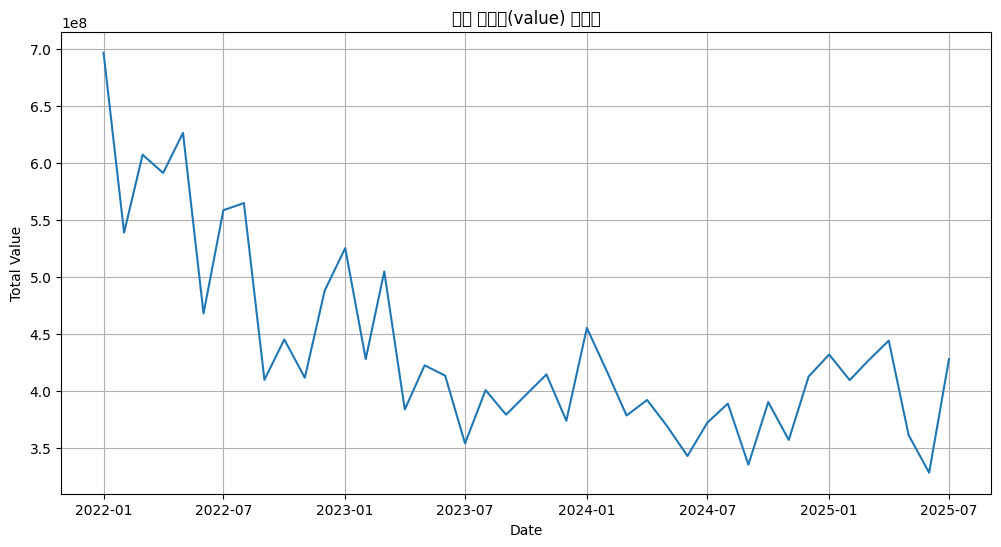

In [54]:
total_monthly = montly.groupby('date', as_index=False)['value'].sum()

plt.figure(figsize=(12,6))
plt.plot(total_monthly['date'], total_monthly['value'])
plt.title('전체 무역량(value) 시계열')
plt.xlabel('Date')
plt.ylabel('Total Value')
plt.grid()
plt.show()

In [55]:
top_items =(
    montly.groupby('item_id', as_index=False)['value']
    .sum()
    .sort_values(by='value', ascending=False)
    .head(5)
)
top_item_ids = top_items['item_id'].tolist()
print(top_item_ids)

['FCYBOAXC', 'ATLDMDBO', 'GYHKIVQT', 'CCLHWFWF', 'STZDBITS']


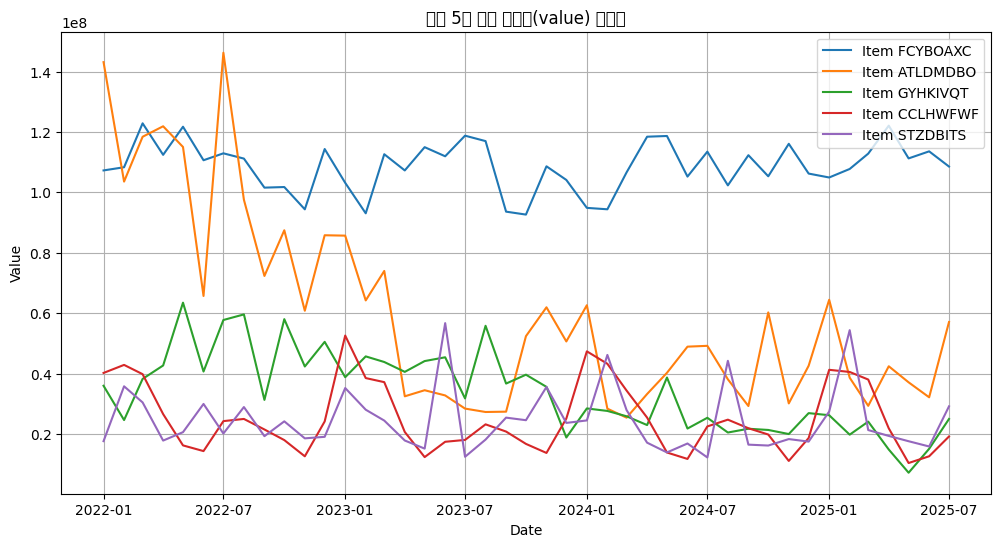

In [56]:
top_montly = montly[montly['item_id'].isin(top_item_ids)]
plt.figure(figsize=(12,6))
for item_id in top_item_ids:
    item_data = top_montly[top_montly['item_id'] == item_id]
    plt.plot(item_data['date'], item_data['value'], label=f'Item {item_id}')
plt.title('상위 5개 품목 무역량(value) 시계열')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

In [57]:
pivot_value = montly.pivot(index="date", columns="item_id", values="value")
pivot_value.head()

item_id,AANGBULD,AHMDUILJ,ANWUJOKX,APQGTRMF,ATLDMDBO,AXULOHBQ,BEZYMBBT,BJALXPFS,BLANHGYY,BSRMSVTC,...,XIFHSOWQ,XIIEJNEE,XIPPENFQ,XMKRPGLB,XUOIQPFL,YSYHGLQK,ZCELVYQU,ZGJXVMNI,ZKENOUDA,ZXERAXWP
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,14276.0,242705.0,NaN,383999.0,143097177.0,11429.0,6034752.0,352532.0,NaN,1216269.0,...,7718.0,NaN,108699.0,879207.0,10871069.0,NaN,373859.0,1154724.0,122627.0,10867.0
2022-02-01,52347.0,120847.0,NaN,512813.0,103568323.0,16365.0,6221091.0,218947.0,891.0,156005.0,...,24829.0,81.0,78853.0,1650028.0,9573079.0,543.0,59900.0,1337622.0,38162.0,675.0
2022-03-01,53549.0,197317.0,NaN,217064.0,118403737.0,47307.0,4611537.0,331472.0,NaN,801085.0,...,102019.0,3198210.0,172237.0,1831614.0,8774783.0,766.0,31158.0,1662893.0,3592.0,20548.0
2022-04-01,NaN,126142.0,63580.0,470398.0,121873741.0,59524.0,5202039.0,17480.0,NaN,365605.0,...,33215.0,NaN,89681.0,705567.0,4713153.0,1108.0,594407.0,1561647.0,5613.0,662.0
2022-05-01,26997.0,71730.0,81670.0,539873.0,115024617.0,74828.0,6889516.0,234330.0,23141.0,168725.0,...,82348.0,81175.0,81387.0,1718634.0,4612292.0,859.0,648232.0,1603223.0,33924.0,18949.0


In [58]:
train_rows = []

def create_pair_training(A, B):
    series_A = pivot_value[A].dropna()
    series_B = pivot_value[B].dropna()

    # 공통 날짜만 사용
    idx = series_A.index.intersection(series_B.index)

    a = series_A.loc[idx]
    b = series_B.loc[idx]

    df = pd.DataFrame({
        "A_t":     a,
        "A_t_1":   a.shift(1),
        "A_t_2":   a.shift(2),
        "B_t":     b,
        "B_t_1":   b.shift(1),
        "B_t_2":   b.shift(2),
        "B_next":  b.shift(-1)     # 타겟(B_{t+1})
    }).dropna()

    df["leading_item_id"] = A
    df["following_item_id"] = B
    return df

for _, row in sample.iterrows():
    A = row["leading_item_id"]
    B = row["following_item_id"]
    df_pair = create_pair_training(A, B)
    train_rows.append(df_pair)

train_data = pd.concat(train_rows, ignore_index=True)
train_data.head()

,A_t,A_t_1,A_t_2,B_t,B_t_1,B_t_2,B_next,leading_item_id,following_item_id
0,51123.0,109074.0,60193.0,328915.0,312664.0,267743.0,268882.0,DEWLVASR,ELQGMQWE
1,7111.0,51123.0,109074.0,268882.0,328915.0,312664.0,278877.0,DEWLVASR,ELQGMQWE
2,157348.0,7111.0,51123.0,278877.0,268882.0,328915.0,324921.0,DEWLVASR,ELQGMQWE
3,313372.0,157348.0,7111.0,324921.0,278877.0,268882.0,460092.0,DEWLVASR,ELQGMQWE
4,104852.0,313372.0,157348.0,460092.0,324921.0,278877.0,436311.0,DEWLVASR,ELQGMQWE


In [59]:
from sklearn.model_selection import train_test_split
feature_cols = ["A_t", "A_t_1", "A_t_2", "B_t", "B_t_1", "B_t_2"]

X = train_data[feature_cols]
y = train_data["B_next"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

X_train.shape, X_valid.shape

((239131, 6), (59783, 6))

In [60]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

model = lgb.LGBMRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

pred_valid = model.predict(X_valid)
rmse = mean_squared_error(y_valid, pred_valid)

print("Validation RMSE :", rmse)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000413 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 239131, number of used features: 6
[LightGBM] [Info] Start training from score 4870376.270693
Validation RMSE : 6807674806171.165


In [61]:
def get_last_three(series):
    """
    시계열 series에서 마지막 3개 값을 안전하게 반환.
    길이가 3 미만이면 마지막 값을 복제해서 채운다.
    길이가 0이면 0으로 채운다.
    반환: (t, t-1, t-2)
    """
    s = series.dropna()
    n = len(s)
    
    if n == 0:
        return 0.0, 0.0, 0.0
    
    if n == 1:
        v0 = s.iloc[-1]
        return v0, v0, v0
    
    if n == 2:
        v0 = s.iloc[-1]
        v1 = s.iloc[-2]
        return v0, v1, v1
    
    # n >= 3
    v0 = s.iloc[-1]
    v1 = s.iloc[-2]
    v2 = s.iloc[-3]
    return v0, v1, v2

def predict_next_month(A, B):
    series_A = pivot_value[A]
    series_B = pivot_value[B]

    # 안전하게 t, t-1, t-2 가져오기
    A_t, A_t_1, A_t_2 = get_last_three(series_A)
    B_t, B_t_1, B_t_2 = get_last_three(series_B)

    X_pred = pd.DataFrame([{
        "A_t": A_t, "A_t_1": A_t_1, "A_t_2": A_t_2,
        "B_t": B_t, "B_t_1": B_t_1, "B_t_2": B_t_2
    }])

    pred = model.predict(X_pred)[0]
    return pred

In [62]:
preds = []

for _, row in sample.iterrows():
    A = row["leading_item_id"]
    B = row["following_item_id"]
    pred = predict_next_month(A, B)
    preds.append(pred)

sample["value"] = preds
sample.head()

,leading_item_id,following_item_id,value
0,DEWLVASR,ELQGMQWE,6.542025e+05
1,DEWLVASR,AHMDUILJ,1.095416e+05
2,DEWLVASR,XIPPENFQ,1.260270e+05
3,DEWLVASR,FTSVTTSR,2.355105e+05
4,DEWLVASR,XMKRPGLB,1.179714e+06


In [63]:
sample.to_csv("submission.csv", index=False)
print("submission.csv saved!")

submission.csv saved!


**모델 재정의**

In [64]:
# 월별 집계: item_id, year, month 기준 value/weight/quantity 합산
monthly = (
    train.groupby(["item_id", "year", "month"], as_index=False)[["value", "weight", "quantity"]]
         .sum()
)

# 날짜 컬럼 생성
monthly["date"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" + monthly["month"].astype(str) + "-01"
)

monthly.sort_values(["item_id", "date"], inplace=True)

# item 메타 정보 (type, hs4는 첫 값 사용)
item_meta = (
    train.groupby("item_id")[["type", "hs4"]]
         .agg("first")
         .reset_index()
         .set_index("item_id")
)

monthly.head(), item_meta.head()

(    item_id  year  month    value    weight  quantity       date
 0  AANGBULD  2022      1  14276.0   17625.0       0.0 2022-01-01
 1  AANGBULD  2022      2  52347.0   67983.0       0.0 2022-02-01
 2  AANGBULD  2022      3  53549.0   69544.0       0.0 2022-03-01
 3  AANGBULD  2022      5  26997.0   34173.0       0.0 2022-05-01
 4  AANGBULD  2022      6  84489.0  103666.0       0.0 2022-06-01,
           type   hs4
 item_id             
 AANGBULD     1  4810
 AHMDUILJ     1  2102
 ANWUJOKX     1  4403
 APQGTRMF     1  8105
 ATLDMDBO     1  2814)

In [65]:
def build_features_for_pair(A, B, include_target=True, max_lag=12):
    """
    A(leading_item_id), B(following_item_id)에 대해
    고급 feature들을 생성한 DataFrame을 반환.
    
    include_target=True 이면 B_next(B_{t+1})까지 포함 (학습용)
    False이면 타겟 없이 feature만 생성 (예측용).
    """
    # A, B 시계열
    series_A = pivot_value[A].dropna()
    series_B = pivot_value[B].dropna()
    
    # 공통 날짜만 사용
    idx = series_A.index.intersection(series_B.index)
    if len(idx) == 0:
        # 공통 구간이 없으면 빈 DF
        return pd.DataFrame()
    
    a = series_A.loc[idx]
    b = series_B.loc[idx]
    
    df = pd.DataFrame(index=idx)
    df["date"] = idx
    df["A"] = a
    df["B"] = b
    
    # === Lag features ===
    for lag in range(1, max_lag + 1):
        df[f"A_lag{lag}"] = df["A"].shift(lag)
        df[f"B_lag{lag}"] = df["B"].shift(lag)
    
    # === Rolling features ===
    for win in [3, 6, 12]:
        df[f"A_roll{win}_mean"] = df["A"].rolling(win).mean()
        df[f"B_roll{win}_mean"] = df["B"].rolling(win).mean()
    
    df["A_roll3_std"] = df["A"].rolling(3).std()
    df["B_roll3_std"] = df["B"].rolling(3).std()
    
    # === 변화율 ===
    df["A_pct_change"] = df["A"].pct_change()
    df["B_pct_change"] = df["B"].pct_change()
    
    # === Cross features ===
    df["A_minus_B"] = df["A"] - df["B"]
    df["A_div_B"] = df["A"] / (df["B"] + 1)  # 0 division 방지용 +1
    
    # === 날짜 기반 feature ===
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    
    # === item 메타 ===
    # type, hs4를 숫자 코드로 변환해서 사용
    type_A = item_meta.loc[A, "type"] if A in item_meta.index else -1
    hs4_A  = item_meta.loc[A, "hs4"] if A in item_meta.index else -1
    type_B = item_meta.loc[B, "type"] if B in item_meta.index else -1
    hs4_B  = item_meta.loc[B, "hs4"] if B in item_meta.index else -1
    
    df["type_A"] = type_A
    df["hs4_A"]  = hs4_A
    df["type_B"] = type_B
    df["hs4_B"]  = hs4_B
    
    # pair 정보 (나중에 embedding처럼 사용)
    df["leading_item_id"] = A
    df["following_item_id"] = B
    df["pair_id"] = A + "_" + B
    
    # === Target ===
    if include_target:
        df["B_next"] = df["B"].shift(-1)
        # 마지막 시점은 B_next가 없으니 제외
        df = df.dropna(subset=["B_next"])
    
    # feature 계산으로 생긴 NaN 제거
    feature_cols = [c for c in df.columns if c not in ["B_next"]]
    if include_target:
        df = df.dropna(subset=feature_cols + ["B_next"])
    else:
        df = df.dropna(subset=feature_cols)
    
    return df

In [66]:
pair_dfs = []

for _, row in sample.iterrows():
    A = row["leading_item_id"]
    B = row["following_item_id"]
    df_pair = build_features_for_pair(A, B, include_target=True, max_lag=12)
    if not df_pair.empty:
        pair_dfs.append(df_pair)

train_df = pd.concat(pair_dfs, ignore_index=True)
print("train_df shape:", train_df.shape)
train_df.head()

train_df shape: (212796, 49)


,date,A,B,A_lag1,B_lag1,A_lag2,B_lag2,A_lag3,B_lag3,A_lag4,...,year,month,type_A,hs4_A,type_B,hs4_B,leading_item_id,following_item_id,pair_id,B_next
0,2023-02-01,159834.0,259671.0,36940.0,256429.0,236201.0,430356.0,185367.0,165669.0,103737.0,...,2023,2,1,3038,1,2002,DEWLVASR,ELQGMQWE,DEWLVASR_ELQGMQWE,356704.0
1,2023-03-01,8320.0,356704.0,159834.0,259671.0,36940.0,256429.0,236201.0,430356.0,185367.0,...,2023,3,1,3038,1,2002,DEWLVASR,ELQGMQWE,DEWLVASR_ELQGMQWE,379657.0
2,2023-04-01,40634.0,379657.0,8320.0,356704.0,159834.0,259671.0,36940.0,256429.0,236201.0,...,2023,4,1,3038,1,2002,DEWLVASR,ELQGMQWE,DEWLVASR_ELQGMQWE,139222.0
3,2023-05-01,121985.0,139222.0,40634.0,379657.0,8320.0,356704.0,159834.0,259671.0,36940.0,...,2023,5,1,3038,1,2002,DEWLVASR,ELQGMQWE,DEWLVASR_ELQGMQWE,289045.0
4,2023-06-01,53711.0,289045.0,121985.0,139222.0,40634.0,379657.0,8320.0,356704.0,159834.0,...,2023,6,1,3038,1,2002,DEWLVASR,ELQGMQWE,DEWLVASR_ELQGMQWE,509435.0


In [67]:
# pair_id, leading_item_id, following_item_id 등을 category → code로
for col in ["pair_id", "leading_item_id", "following_item_id"]:
    train_df[col] = train_df[col].astype("category")
    train_df[col + "_code"] = train_df[col].cat.codes

In [68]:
# 타겟: B_next (log1p 변환)
train_df["B_next_log"] = np.log1p(train_df["B_next"])

# 학습에 쓰지 않을 컬럼들
drop_cols = [
    "B_next", "B_next_log", "A", "B",
    "date", "pair_id", "leading_item_id", "following_item_id"
]

feature_cols = [c for c in train_df.columns if c not in drop_cols]

print("Feature count:", len(feature_cols))
feature_cols[:20]

Feature count: 45


['A_lag1',
 'B_lag1',
 'A_lag2',
 'B_lag2',
 'A_lag3',
 'B_lag3',
 'A_lag4',
 'B_lag4',
 'A_lag5',
 'B_lag5',
 'A_lag6',
 'B_lag6',
 'A_lag7',
 'B_lag7',
 'A_lag8',
 'B_lag8',
 'A_lag9',
 'B_lag9',
 'A_lag10',
 'B_lag10']

In [69]:
cutoff_date = pd.Timestamp("2024-07-01")

train_mask = train_df["date"] < cutoff_date
valid_mask = train_df["date"] >= cutoff_date

X_train = train_df.loc[train_mask, feature_cols]
y_train = train_df.loc[train_mask, "B_next_log"]

X_valid = train_df.loc[valid_mask, feature_cols]
y_valid = train_df.loc[valid_mask, "B_next_log"]

X_train.shape, X_valid.shape

((123874, 45), (88922, 45))

In [72]:
model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.005,
    max_depth=-1,
    num_leaves=256,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
)

# 검증 RMSE (log 스케일)
pred_valid_log = model.predict(X_valid)
rmse_log = mean_squared_error(y_valid, pred_valid_log)
print("Validation RMSE (log scale):", rmse_log)

# 원래 스케일로 복원한 뒤 RMSE도 계산해보기
pred_valid = np.expm1(pred_valid_log)
y_valid_real = np.expm1(y_valid)
rmse_real = mean_squared_error(y_valid_real, pred_valid)
print("Validation RMSE (real scale):", rmse_real)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001188 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9763
[LightGBM] [Info] Number of data points in the train set: 123874, number of used features: 43
[LightGBM] [Info] Start training from score 12.799317
Validation RMSE (log scale): 1.4362814161267823
Validation RMSE (real scale): 16058082108292.01


In [73]:
def build_features_for_pair_for_forecast(A, B, max_lag=12):
    """
    예측(타겟 없이)용 feature 생성.
    마지막 시점의 feature 한 행만 반환.
    충분한 데이터가 없으면 빈 DF를 반환.
    """
    df = build_features_for_pair(A, B, include_target=False, max_lag=max_lag)
    if df.empty:
        return df
    # 마지막 시점 한 행만 사용
    return df.iloc[[-1]]  # DataFrame 유지 (행 1개)


def predict_next_month_for_pair(A, B, max_lag=12):
    """
    A, B에 대해 2025-08 value를 예측.
    feature를 만들 수 없으면 간단 baseline(B 마지막 값)을 반환.
    """
    df_feat = build_features_for_pair_for_forecast(A, B, max_lag=max_lag)
    
    if df_feat.empty:
        # feature 만들 수 없으면 B의 마지막 값을 그대로 사용 (naive baseline)
        series_B = pivot_value[B].dropna()
        if len(series_B) == 0:
            return 0.0
        else:
            return float(series_B.iloc[-1])
    
    # train에서 사용한 feature_cols와 동일한 컬럼만 선택
    # 없는 컬럼은 0으로 채워서 맞춰줌
    for col in feature_cols:
        if col not in df_feat.columns:
            df_feat[col] = 0.0
    
    X_pred = df_feat[feature_cols]
    
    pred_log = model.predict(X_pred)[0]
    pred = np.expm1(pred_log)
    # 음수 방지
    if pred < 0:
        pred = 0.0
    return float(pred)

In [74]:
preds = []

for _, row in sample.iterrows():
    A = row["leading_item_id"]
    B = row["following_item_id"]
    pred_value = predict_next_month_for_pair(A, B, max_lag=12)
    preds.append(pred_value)

sample["value"] = preds
sample.head()

,leading_item_id,following_item_id,value
0,DEWLVASR,ELQGMQWE,598728.877810
1,DEWLVASR,AHMDUILJ,106815.759641
2,DEWLVASR,XIPPENFQ,104774.231348
3,DEWLVASR,FTSVTTSR,147039.964420
4,DEWLVASR,XMKRPGLB,780099.173965


In [75]:
sample.to_csv("submission_advanced_lgbm.csv", index=False)
print("Saved: submission_advanced_lgbm.csv")

Saved: submission_advanced_lgbm.csv
